## «Анализ продаж интернет-магазина»

**Цели проекта: Провести исследовательский анализ продаж интернет-магазина и выявить ключевые закономерности в поведении покупателей и продажах.**
  Основные вопросы:
1. Какие категории товаров приносят больше всего выручки?
2. Какие города делают больше заказов?
3. Кто чаще покупает: мужчины или женщины?
4. Какие бренды наиболее популярны?
5. Как менялись продажи со временем?
6. Какие способы оплаты используются чаще всего?

Для того чтобы ответить на вопросы проанализируем 3 таблицы: Заказы, Клиенты, Товары.

Файл с таблицей "Заказы" содержит информацио о сделанных заказов на сайте.  

| Колонка | Определение|
|---|---|
| order_id | Идентификатор заказа |
| customer_id | Идентификатор клиента |
| order_date | Дата покупки |
| product_id | Идентификатор товара |
| quantity | Количество купленного товара |
| price | Цена |
| city | Город |
| payment_method | Способ оплаты |

Файл с таблицей "Клиенты" содержит данные о клиенте.

| Колонка | Определение |
|---|---|
| customer_id | Идентификатор клиента |
| age | Возраст |
| gender | Пол |
| registration_date | Дата регистрации |

Файл с таблицей "Товары" содержит информацию о товарах, которые представлены на сайте.

| Колонка | Определение |
|---|---|
| product_id | Идентификатор товара |
| category | Категория |
| product_name | Название товара |
| brand | Бренд(марка) |

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [52]:
order = pd.read_csv('orders.csv')
order

,order_id,customer_id,order_date,product_id,quantity,price,city,payment_method
0,1,354,2023-09-14,17,3,3975,Екатеринбург,Cash
1,2,196,2024-08-08,15,2,4494,Казань,Online
2,3,203,2023-10-09,20,3,5892,Москва,Online
3,4,410,2023-08-24,8,1,9638,Новосибирск,Cash
4,5,348,2024-11-06,11,2,21345,Санкт-Петербург,Online
...,...,...,...,...,...,...,...,...
4995,4996,299,2024-09-14,17,1,5172,Казань,Online
4996,4997,385,2023-03-28,15,1,10314,Санкт-Петербург,Online
4997,4998,98,2024-08-17,9,3,8000,Москва,Cash
4998,4999,464,2023-05-04,18,2,546,Санкт-Петербург,Online


In [53]:
order.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   order_id        5000 non-null   int64 
 1   customer_id     5000 non-null   int64 
 2   order_date      5000 non-null   object
 3   product_id      5000 non-null   int64 
 4   quantity        5000 non-null   int64 
 5   price           5000 non-null   int64 
 6   city            5000 non-null   object
 7   payment_method  5000 non-null   object
dtypes: int64(5), object(3)
memory usage: 312.6+ KB


In [54]:
order.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
order_id,5000.0,2500.5000,1443.520003,1.0,1250.75,2500.5,3750.25,5000.0
customer_id,5000.0,248.6328,143.815078,1.0,124.00,249.5,372.00,500.0
product_id,5000.0,10.4316,5.791617,1.0,5.00,10.0,15.00,20.0
quantity,5000.0,2.9626,1.412940,1.0,2.00,3.0,4.00,5.0
price,5000.0,22826.8412,30709.665519,500.0,4389.00,8681.0,22852.00,119969.0


In [55]:
customer = pd.read_csv('customers.csv')

In [56]:
customer.head(10)

,customer_id,age,gender,registration_date
0,1,18,Male,2024-07-09
1,2,45,Female,2024-03-09
2,3,35,Male,2023-09-18
3,4,31,Female,2025-04-23
4,5,24,Male,2025-02-07
5,6,42,Male,2025-08-17
6,7,40,Female,2025-01-30
7,8,56,Female,2026-02-24
8,9,20,Female,2024-04-05
9,10,52,Male,2026-05-03


In [57]:
customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   customer_id        500 non-null    int64 
 1   age                500 non-null    int64 
 2   gender             500 non-null    object
 3   registration_date  500 non-null    object
dtypes: int64(2), object(2)
memory usage: 15.8+ KB


In [58]:
customer.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
customer_id,500.0,250.500,144.481833,1.0,125.75,250.5,375.25,500.0
age,500.0,39.596,12.336497,18.0,29.00,39.5,50.00,60.0


In [59]:
product = pd.read_csv('products.csv')

In [60]:
product.head(10)

,product_id,category,product_name,brand
0,1,Электроника,Наушники,Samsung
1,2,Электроника,Смартфон,Apple
2,3,Электроника,Ноутбук,Adidas
3,4,Электроника,Планшет,Nike
4,5,Электроника,Клавиатура,Nike
5,6,Одежда,Футболка,Xiaomi
6,7,Одежда,Куртка,Samsung
7,8,Одежда,Джинсы,Samsung
8,9,Одежда,Кроссовки,Philips
9,10,Одежда,Худи,Apple


In [61]:
product.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   product_id    20 non-null     int64 
 1   category      20 non-null     object
 2   product_name  20 non-null     object
 3   brand         20 non-null     object
dtypes: int64(1), object(3)
memory usage: 768.0+ bytes


In [62]:
product.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
product_id,20.0,10.5,5.91608,1.0,5.75,10.5,15.25,20.0


## Часть 1. Преобразовываем данные
**Для начала преобразуем данные, создадим новые колонки необходимые для исследования.**

In [63]:
order['order_date'] = pd.to_datetime(order['order_date']) #Колонка 'registration_date' имела тип object. Преобразуем ее в тип данных to_datetime, чтобы комфортнее работатьorder['order_date'] = pd.to_datetime(customer[''']) #Колонка 'registration_date' имела тип object. Преобразуем ее в тип данных to_datetime, чтобы комфортнее работать

In [64]:
order['revenue'] = order['quantity'] * order['price'] #Добавим колонку revenue, чтобы узнать итоговую стоимость товара

In [65]:
order.head(10)

,order_id,customer_id,order_date,product_id,quantity,price,city,payment_method,revenue
0,1,354,2023-09-14,17,3,3975,Екатеринбург,Cash,11925
1,2,196,2024-08-08,15,2,4494,Казань,Online,8988
2,3,203,2023-10-09,20,3,5892,Москва,Online,17676
3,4,410,2023-08-24,8,1,9638,Новосибирск,Cash,9638
4,5,348,2024-11-06,11,2,21345,Санкт-Петербург,Online,42690
5,6,226,2023-02-04,14,1,11123,Новосибирск,Cash,11123
6,7,213,2023-06-29,15,2,11705,Санкт-Петербург,Card,23410
7,8,426,2023-06-18,17,5,2732,Казань,Cash,13660
8,9,494,2023-03-19,12,3,4773,Санкт-Петербург,Card,14319
9,10,405,2024-02-09,1,4,115458,Москва,Cash,461832


In [66]:
order['month'] = order['order_date'].dt.month #Добавим колонки month и year
order['year'] = order['order_date'].dt.year

In [67]:
order

,order_id,customer_id,order_date,product_id,quantity,price,city,payment_method,revenue,month,year
0,1,354,2023-09-14,17,3,3975,Екатеринбург,Cash,11925,9,2023
1,2,196,2024-08-08,15,2,4494,Казань,Online,8988,8,2024
2,3,203,2023-10-09,20,3,5892,Москва,Online,17676,10,2023
3,4,410,2023-08-24,8,1,9638,Новосибирск,Cash,9638,8,2023
4,5,348,2024-11-06,11,2,21345,Санкт-Петербург,Online,42690,11,2024
...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,299,2024-09-14,17,1,5172,Казань,Online,5172,9,2024
4996,4997,385,2023-03-28,15,1,10314,Санкт-Петербург,Online,10314,3,2023
4997,4998,98,2024-08-17,9,3,8000,Москва,Cash,24000,8,2024
4998,4999,464,2023-05-04,18,2,546,Санкт-Петербург,Online,1092,5,2023


In [68]:
order['year_month'] = order['order_date'].dt.to_period('M').astype(str)
order

,order_id,customer_id,order_date,product_id,quantity,price,city,payment_method,revenue,month,year,year_month
0,1,354,2023-09-14,17,3,3975,Екатеринбург,Cash,11925,9,2023,2023-09
1,2,196,2024-08-08,15,2,4494,Казань,Online,8988,8,2024,2024-08
2,3,203,2023-10-09,20,3,5892,Москва,Online,17676,10,2023,2023-10
3,4,410,2023-08-24,8,1,9638,Новосибирск,Cash,9638,8,2023,2023-08
4,5,348,2024-11-06,11,2,21345,Санкт-Петербург,Online,42690,11,2024,2024-11
...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,299,2024-09-14,17,1,5172,Казань,Online,5172,9,2024,2024-09
4996,4997,385,2023-03-28,15,1,10314,Санкт-Петербург,Online,10314,3,2023,2023-03
4997,4998,98,2024-08-17,9,3,8000,Москва,Cash,24000,8,2024,2024-08
4998,4999,464,2023-05-04,18,2,546,Санкт-Петербург,Online,1092,5,2023,2023-05


**Соединим таблицы для более детального анализа.**

In [69]:
order_customer = pd.merge(order, customer, on = 'customer_id')

In [70]:
order_customer

,order_id,customer_id,order_date,product_id,quantity,price,city,payment_method,revenue,month,year,year_month,age,gender,registration_date
0,1,354,2023-09-14,17,3,3975,Екатеринбург,Cash,11925,9,2023,2023-09,37,Male,2023-11-05
1,144,354,2024-05-15,7,3,6235,Казань,Cash,18705,5,2024,2024-05,37,Male,2023-11-05
2,234,354,2024-05-27,17,3,5321,Санкт-Петербург,Cash,15963,5,2024,2024-05,37,Male,2023-11-05
3,872,354,2024-11-22,4,3,85043,Санкт-Петербург,Cash,255129,11,2024,2024-11,37,Male,2023-11-05
4,1978,354,2024-04-03,11,1,7162,Москва,Online,7162,4,2024,2024-04,37,Male,2023-11-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,3942,234,2023-02-20,18,2,5638,Санкт-Петербург,Card,11276,2,2023,2023-02,27,Male,2024-02-27
4996,3995,234,2024-05-09,5,5,23114,Казань,Cash,115570,5,2024,2024-05,27,Male,2024-02-27
4997,4294,234,2024-08-07,9,5,9174,Санкт-Петербург,Online,45870,8,2024,2024-08,27,Male,2024-02-27
4998,4904,234,2023-10-22,19,2,5314,Казань,Card,10628,10,2023,2023-10,27,Male,2024-02-27


In [71]:
df = pd.merge(order_customer, product, on = 'product_id')

In [72]:
df

,order_id,customer_id,order_date,product_id,quantity,price,city,payment_method,revenue,month,year,year_month,age,gender,registration_date,category,product_name,brand
0,1,354,2023-09-14,17,3,3975,Екатеринбург,Cash,11925,9,2023,2023-09,37,Male,2023-11-05,Красота,Шампунь,Philips
1,234,354,2024-05-27,17,3,5321,Санкт-Петербург,Cash,15963,5,2024,2024-05,37,Male,2023-11-05,Красота,Шампунь,Philips
2,4814,354,2024-11-25,17,2,2832,Москва,Cash,5664,11,2024,2024-11,37,Male,2023-11-05,Красота,Шампунь,Philips
3,2079,213,2023-02-22,17,4,1568,Санкт-Петербург,Card,6272,2,2023,2023-02,60,Female,2025-01-13,Красота,Шампунь,Philips
4,4573,213,2023-11-30,17,5,1634,Екатеринбург,Cash,8170,11,2023,2023-11,60,Female,2025-01-13,Красота,Шампунь,Philips
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,2385,83,2023-02-26,3,2,84847,Казань,Card,169694,2,2023,2023-02,18,Male,2025-07-02,Электроника,Ноутбук,Adidas
4996,4141,134,2024-08-31,3,4,101032,Санкт-Петербург,Card,404128,8,2024,2024-08,43,Male,2025-10-22,Электроника,Ноутбук,Adidas
4997,3258,414,2023-04-08,3,5,107253,Казань,Cash,536265,4,2023,2023-04,40,Female,2025-12-01,Электроника,Ноутбук,Adidas
4998,2151,379,2023-11-04,3,5,57682,Екатеринбург,Card,288410,11,2023,2023-11,34,Male,2023-11-14,Электроника,Ноутбук,Adidas


# Часть 2. Анализ данных

## **1. Посчитаем общую выручку, средний чек и количество заказов за 2024 год.**

In [73]:
df_2024 = df[df['year'] == 2024]

In [74]:
df_2024

,order_id,customer_id,order_date,product_id,quantity,price,city,payment_method,revenue,month,year,year_month,age,gender,registration_date,category,product_name,brand
1,234,354,2024-05-27,17,3,5321,Санкт-Петербург,Cash,15963,5,2024,2024-05,37,Male,2023-11-05,Красота,Шампунь,Philips
2,4814,354,2024-11-25,17,2,2832,Москва,Cash,5664,11,2024,2024-11,37,Male,2023-11-05,Красота,Шампунь,Philips
6,4677,426,2024-10-20,17,1,893,Москва,Online,893,10,2024,2024-10,44,Male,2023-11-13,Красота,Шампунь,Philips
7,1105,384,2024-04-20,17,1,5991,Екатеринбург,Cash,5991,4,2024,2024-04,56,Female,2023-12-17,Красота,Шампунь,Philips
9,3285,332,2024-10-10,17,1,1218,Екатеринбург,Cash,1218,10,2024,2024-10,44,Female,2025-05-29,Красота,Шампунь,Philips
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4987,1118,393,2024-09-05,3,1,18825,Екатеринбург,Card,18825,9,2024,2024-09,35,Male,2024-02-01,Электроника,Ноутбук,Adidas
4989,3611,68,2024-08-12,3,3,99760,Москва,Cash,299280,8,2024,2024-08,54,Male,2024-06-28,Электроника,Ноутбук,Adidas
4992,2921,36,2024-11-30,3,5,20775,Екатеринбург,Card,103875,11,2024,2024-11,43,Female,2024-07-05,Электроника,Ноутбук,Adidas
4996,4141,134,2024-08-31,3,4,101032,Санкт-Петербург,Card,404128,8,2024,2024-08,43,Male,2025-10-22,Электроника,Ноутбук,Adidas


In [75]:
 df_2024['revenue'].sum() #Посчитаем общую выручку за 2024 год

157924541

In [76]:
df_2024['revenue'].mean().round(2) # Средний чек

66438.6

In [77]:
df_2024['quantity'].sum() # Количество заказов за 2024 год

6961

## 2. Найдем самые популярные товары и товар с наибольшей выручкой

In [78]:
df_2024.groupby('product_name').sum().sort_values('price', ascending = False)

,order_id,customer_id,product_id,quantity,price,revenue,month,year,age
product_name,,,,,,,,,
Наушники,314398,33686,132,385,8788015,25152843,772,267168,5179
Смартфон,315467,31176,254,364,8637033,24787726,703,257048,5230
Ноутбук,330968,33014,393,382,8072827,23280581,795,265144,5282
Планшет,305140,27902,456,325,7579202,22927179,612,230736,4445
Клавиатура,278511,27420,585,347,7514273,21654217,724,236808,4672
Стул,282105,29364,1440,363,1685996,5173850,688,242880,4449
Чайник,323116,34503,1890,389,1598860,4868514,798,255024,4894
Плед,309010,29784,1610,321,1543887,4112078,658,232760,4687
Стол,307565,29275,1573,345,1504244,4305013,770,244904,4508


**Исходя из данных, можно сделать вывод, что самым прибыльным товаром является "Наушники", выручка составляет 25 152 843 руб. На втором месте "Смартфон" с выручкой 24 787 726, на третьем - "Ноутбук" 23 280 581.**

In [79]:
df_2024.groupby('product_name').sum().sort_values('quantity', ascending = False)

,order_id,customer_id,product_id,quantity,price,revenue,month,year,age
product_name,,,,,,,,,
Парфюм,332916,35892,2484,421,522996,1629402,926,279312,5496
Шампунь,341879,31720,2261,395,511578,1522805,783,269192,5200
Чайник,323116,34503,1890,389,1598860,4868514,798,255024,4894
Наушники,314398,33686,132,385,8788015,25152843,772,267168,5179
Ноутбук,330968,33014,393,382,8072827,23280581,795,265144,5282
Худи,340467,35537,1270,379,848716,2557241,782,257048,4778
Смартфон,315467,31176,254,364,8637033,24787726,703,257048,5230
Стул,282105,29364,1440,363,1685996,5173850,688,242880,4449
Кроссовки,305431,30065,1071,351,833021,2452161,662,240856,4912


**Самым популярным товаром является "Парфюм". За 2024 год продали 421 шт. На втором месте "Шампунь", продано 395 шт. На третьем - "Чайник, 389 шт."**

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 [Text(0, 0, 'Наушники'),
  Text(1, 0, 'Смартфон'),
  Text(2, 0, 'Ноутбук'),
  Text(3, 0, 'Планшет'),
  Text(4, 0, 'Клавиатура'),
  Text(5, 0, 'Стул'),
  Text(6, 0, 'Чайник'),
  Text(7, 0, 'Стол'),
  Text(8, 0, 'Плед'),
  Text(9, 0, 'Лампа')])

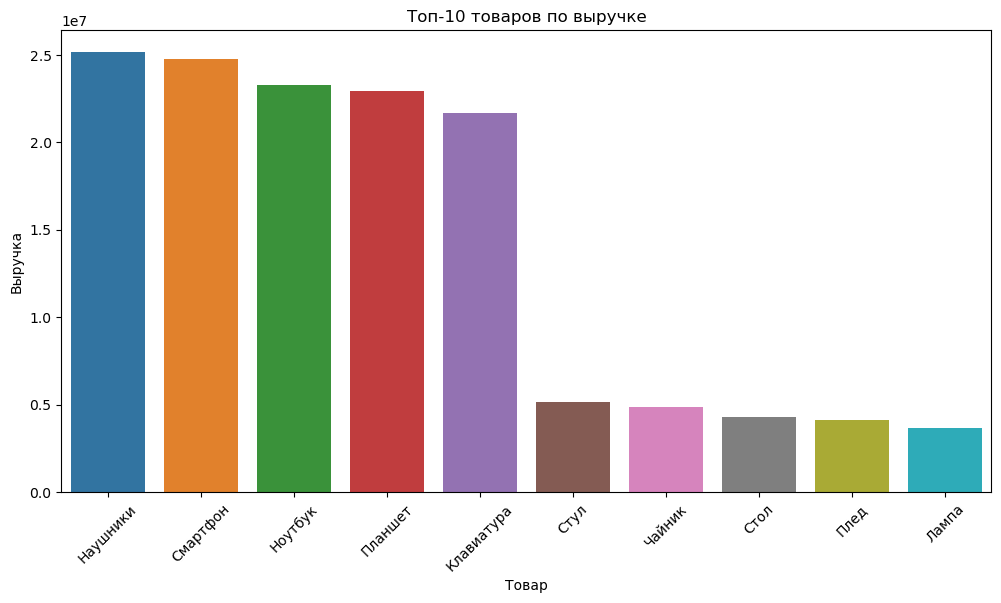

In [80]:
top_products = (
    df_2024.groupby('product_name')['revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_products,
    x='product_name',
    y='revenue'
)

plt.title('Топ-10 товаров по выручке')
plt.xlabel('Товар')
plt.ylabel('Выручка')

plt.xticks(rotation=45)

## 3. Далее сделаем анализ по брендам. Найдем топ брендов по количеству и стоимости

In [81]:
df_2024.groupby('brand').sum().sort_values('price', ascending = False)

,order_id,customer_id,product_id,quantity,price,revenue,month,year,age
brand,,,,,,,,,
Nike,1801366,177450,8420,2062,19082506,55807681,4325,1441088,27947
Apple,1224523,125707,4481,1433,12242230,35899039,2870,965448,18741
Samsung,1110895,116192,3226,1371,11924766,34473439,2668,955328,17915
Adidas,578420,57654,2353,679,8426806,24342798,1371,463496,9145
Philips,647310,61785,3332,746,1344599,3974966,1445,510048,10112
Xiaomi,300660,29419,720,348,765427,2164060,690,242880,4703
L'Oreal,298048,30085,2185,322,443539,1262558,712,232760,4435


**"Nike" является брендом с самой большой выручкой 19 082 506. Далее "Apple" - 12 242 230. Затем "Samsung" с выручкой 11 924 766.**

In [82]:
df_2024.groupby('brand').sum().sort_values('quantity', ascending = False)

,order_id,customer_id,product_id,quantity,price,revenue,month,year,age
brand,,,,,,,,,
Nike,1801366,177450,8420,2062,19082506,55807681,4325,1441088,27947
Apple,1224523,125707,4481,1433,12242230,35899039,2870,965448,18741
Samsung,1110895,116192,3226,1371,11924766,34473439,2668,955328,17915
Philips,647310,61785,3332,746,1344599,3974966,1445,510048,10112
Adidas,578420,57654,2353,679,8426806,24342798,1371,463496,9145
Xiaomi,300660,29419,720,348,765427,2164060,690,242880,4703
L'Oreal,298048,30085,2185,322,443539,1262558,712,232760,4435


**На этой таблице мы видим, что по самыми полуряными брендами являются те же самые компании, которые принесли больше выручки. "Nike" продано 2 062 шт. "Apple" - 1 433 шт. "Samsung" - 1 371 шт.**


## 4. Теперь сделаем анализ по городам

In [83]:
df_2024.groupby('city').sum().sort_values('price', ascending = False)

,order_id,customer_id,product_id,quantity,price,revenue,month,year,age
city,,,,,,,,,
Казань,1222199,121856,5136,1495,11585715,36094557,2937,1001880,18969
Новосибирск,1261831,124708,5203,1432,11492590,31718997,3005,1007952,19854
Москва,1199835,118716,4643,1340,11261893,32765443,2652,943184,18758
Екатеринбург,1187784,120136,5089,1401,10057213,28620221,2810,973544,18717
Санкт-Петербург,1089573,112876,4646,1293,9832462,28725323,2677,884488,16700


**По таблице мы видим, что городом с самой большой выручкой является Казан. Затем Новосибирск и Москва**

In [84]:
df_2024.groupby('city').sum().sort_values('quantity', ascending = False)

,order_id,customer_id,product_id,quantity,price,revenue,month,year,age
city,,,,,,,,,
Казань,1222199,121856,5136,1495,11585715,36094557,2937,1001880,18969
Новосибирск,1261831,124708,5203,1432,11492590,31718997,3005,1007952,19854
Екатеринбург,1187784,120136,5089,1401,10057213,28620221,2810,973544,18717
Москва,1199835,118716,4643,1340,11261893,32765443,2652,943184,18758
Санкт-Петербург,1089573,112876,4646,1293,9832462,28725323,2677,884488,16700


**Город, где чаще делают заказы является Казань, затем Новосибирск и Екатеринбург.**

## 5. Пранализируем покакупателей по возрасту и полу на основе графика

Text(0, 0.5, 'Количество покупателей')

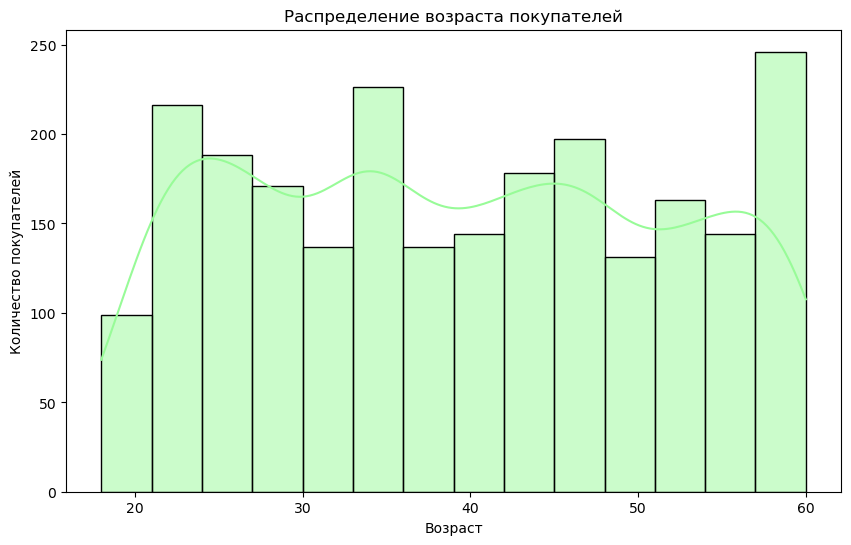

In [85]:
plt.figure(figsize=(10,6))

sns.histplot(data = df_2024['age'], color = '#98FB98', kde = True)

plt.title('Распределение возраста покупателей')
plt.xlabel('Возраст')
plt.ylabel('Количество покупателей')


**По графику можно сделать вывод, что возраст покупателей распределён достаточно равномерно, без сильных перекосов в сторону одной возрастной группы. Наиболее активными являются пользователи в возрасте примерно от 20 до 60 лет.**

Text(0, 0.5, 'Количество')

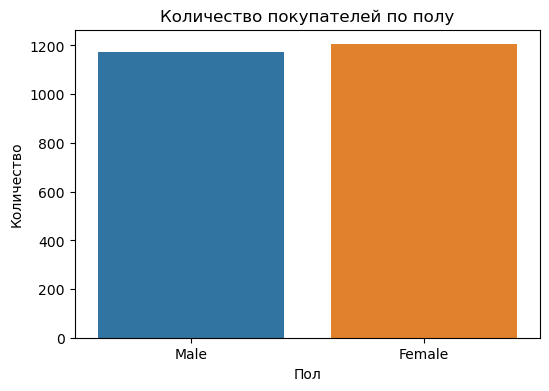

In [86]:
plt.figure(figsize=(6,4))

sns.countplot(data=df_2024, x='gender')

plt.title('Количество покупателей по полу')
plt.xlabel('Пол')
plt.ylabel('Количество')

**Разница между количесвом покупок мужчин и женщин незначительна. Это может означать, что продукция на сайте достаточно разнообразна для мужской и женской аудитории.**

Text(0, 0.5, 'Количество')

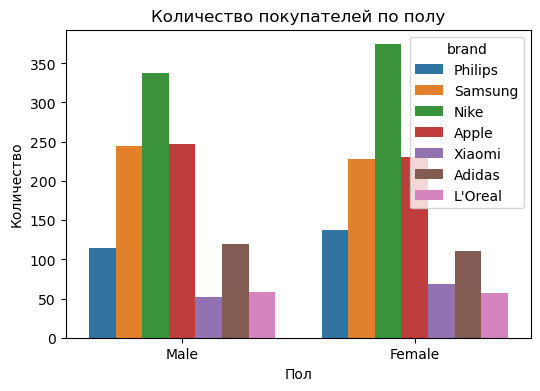

In [87]:
plt.figure(figsize=(6,4))

sns.countplot(data=df_2024, x='gender', hue = 'brand')

plt.title('Количество покупателей по полу')
plt.xlabel('Пол')
plt.ylabel('Количество')

**Если сделать анализ по брендам, то можно увидеть, что разница совсем не значительна. Единственно бренд "Nike" более популярен у женщин, еще бренд "Xiaomi" и "Philips".**

Text(0, 0.5, 'Выручка')

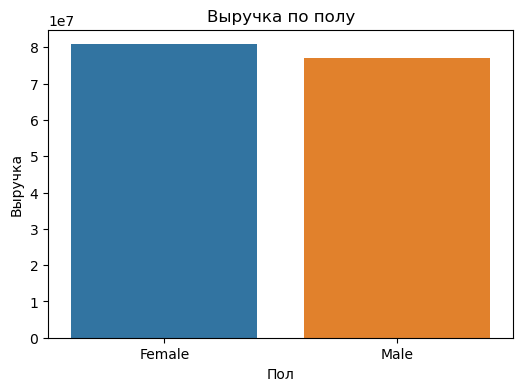

In [88]:
gender_revenue = df_2024.groupby('gender')['revenue'].sum().reset_index()

plt.figure(figsize=(6,4))

sns.barplot(data=gender_revenue,
            x='gender',
            y='revenue')

plt.title('Выручка по полу')
plt.xlabel('Пол')
plt.ylabel('Выручка')

**Несмотря на примерно одинаковое количество покупателей, женщины приносят немного больше выручки.**

## 6. В этом шаге сделаем анализ выручки по категориям

In [89]:
category_revenue = (
    df.groupby('category')['revenue']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

category_revenue

,category,revenue
0,Электроника,252815518
1,Дом,47654834
2,Одежда,23967666
3,Красота,14033146


(array([0, 1, 2, 3]),
 [Text(0, 0, 'Электроника'),
  Text(1, 0, 'Дом'),
  Text(2, 0, 'Одежда'),
  Text(3, 0, 'Красота')])

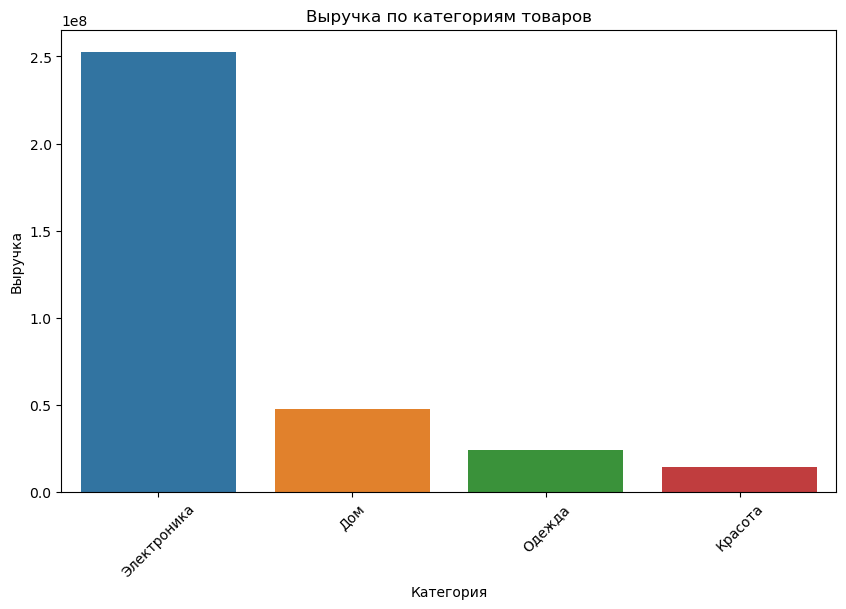

In [90]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=category_revenue,
    x='category',
    y='revenue'
)

plt.title('Выручка по категориям товаров')
plt.xlabel('Категория')
plt.ylabel('Выручка')

plt.xticks(rotation=45)

**Наибольшую выручку приносят категория "Электроника". Это может говорить о высоком спросе на данные товары.**

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

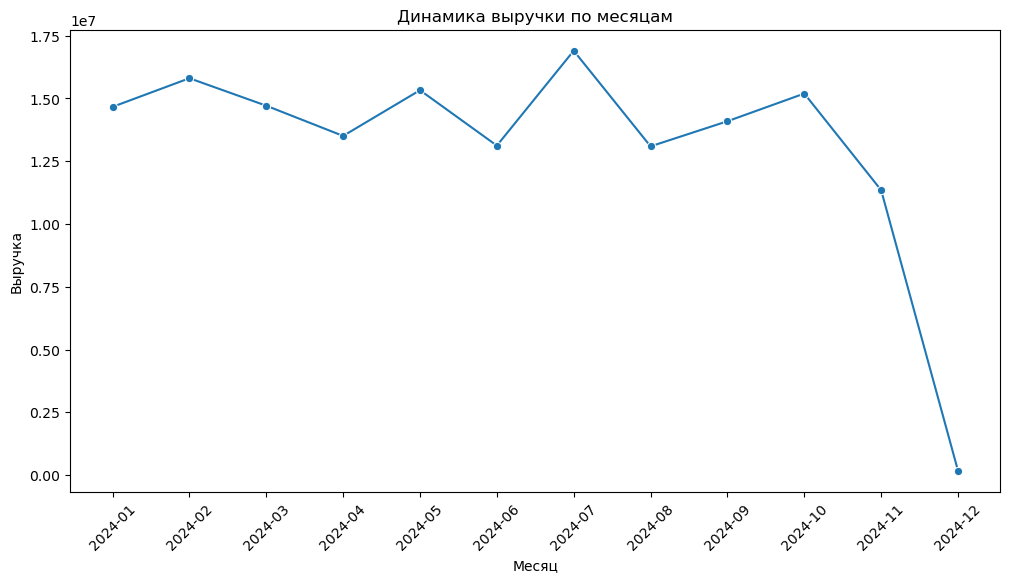

In [91]:
monthly_revenue = (
    df_2024.groupby('year_month')['revenue']
    .sum()
    .reset_index()
)

plt.figure(figsize=(12,6))

sns.lineplot(
    data=monthly_revenue,
    x='year_month',
    y='revenue',
    marker='o'
)

plt.title('Динамика выручки по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Выручка')

plt.xticks(rotation=45)

**В течение большей части 2024 года выручка компании оставалась относительно стабильной, без резких колебаний. Наибольшая выручка наблюдалась в июле, что может быть связано с сезонным ростом спроса или активностью маркетинговой компании. В декабре выручка оказалось 0, либо предосталены неполные данные, либо магазин закрылся**

## 7. На этом шаге проанализируем самые популярные способы оплаты

In [92]:
df_2024['payment_method'].value_counts()

Card      812
Online    785
Cash      780
Name: payment_method, dtype: int64

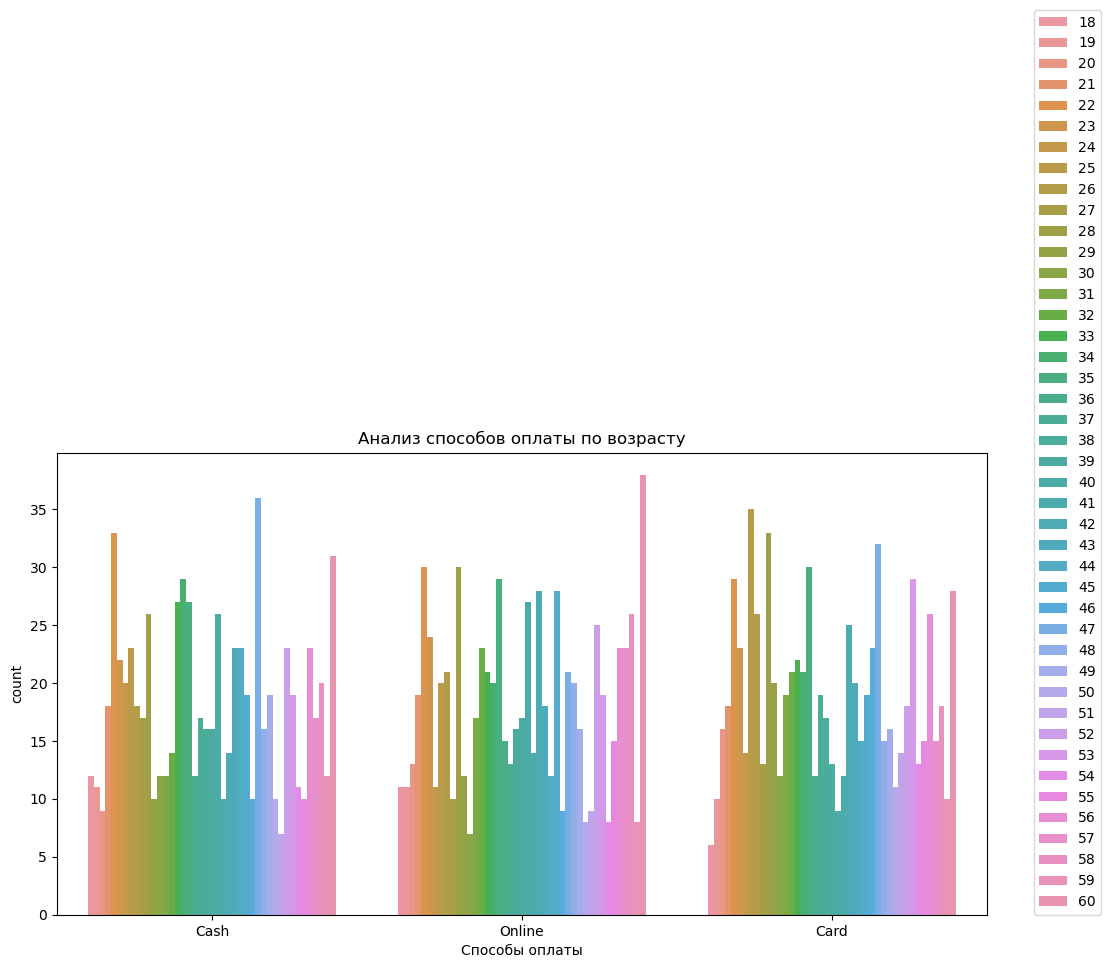

In [93]:
plt.figure(figsize=(12,6))
sns.countplot(data = df_2024, x = 'payment_method', hue = 'age')
plt.title('Анализ способов оплаты по возрасту')
plt.xlabel('Способы оплаты')
plt.legend(loc=(1.05,0))

**Анализ показывает, что способы оплаты распределены относительно равномерно между различными возрастными категориями покупателей. Наиболее популярным способом оплаты являются банковские карты, что может отражать высокий уровень распространения безналичных платежей.**

## 8. Корреляция

In [94]:
numeric_df_2024 = df_2024[['age', 'quantity', 'price', 'revenue']]

In [95]:
numeric_df_2024.head(10)

,age,quantity,price,revenue
1,37,3,5321,15963
2,37,2,2832,5664
6,44,1,893,893
7,56,1,5991,5991
9,44,1,1218,1218
10,35,3,1549,4647
11,35,1,2923,2923
12,45,5,1264,6320
14,25,4,3795,15180
16,19,5,5576,27880


In [96]:
corr_matrix = numeric_df_2024.corr()

In [97]:
corr_matrix.head()

,age,quantity,price,revenue
age,1.000000,-0.000533,0.045023,0.038889
quantity,-0.000533,1.000000,-0.008651,0.302938
price,0.045023,-0.008651,1.000000,0.856452
revenue,0.038889,0.302938,0.856452,1.000000


Text(0.5, 1.0, 'Корреляция признаков')

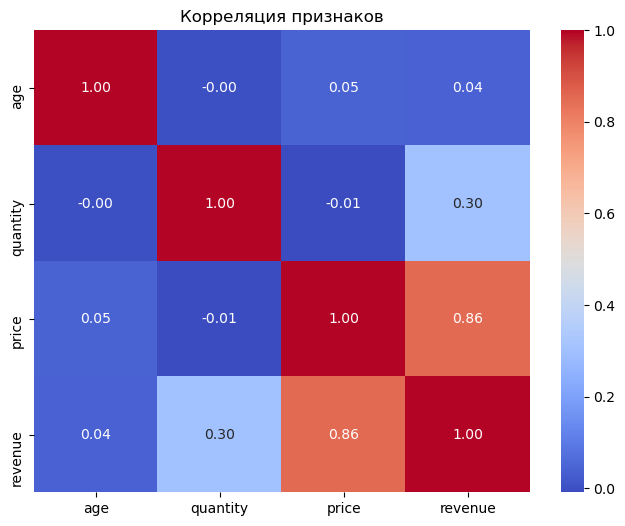

In [98]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Корреляция признаков')


**Наиболее сильная положительная корреляция наблюдается между ценой товара (price) и выручкой (revenue) — коэффициент корреляции составляет 0.86. Это говорит о том, что более дорогие товары вносят основной вклад в общую выручку компании. Между количеством товаров (quantity) и выручкой наблюдается умеренная положительная связь (0.30). Возраст покупателей (age) практически не связан с другими признаками**

## 9. Отвечаем на основные вопросы и делаем общий вывод

**Основные вопросы:**
1. Какие категории товаров приносят больше всего выручки?
**Ответ: Самым прибыльным товаром является "Наушники", выручка составляет 25 152 843 руб. На втором месте "Смартфон" с выручкой 24 787 726, на третьем - "Ноутбук" 23 280 581.**
2. Какие города делают больше заказов?
**Ответ: Городом с самой большой выручкой является Казан. Затем Новосибирск и Москва**
3. Кто чаще покупает: мужчины или женщины?
**Ответ: Разница между количесвом покупок мужчин и женщин незначительна. Это может означать, что продукция на сайте достаточно разнообразна для мужской и женской аудитории.**
4. Какие бренды наиболее популярны?
**Ответ: Самыми полуряными брендами являются те же самые компании, которые принесли больше выручки. "Nike" продано 2 062 шт. "Apple" - 1 433 шт. "Samsung" - 1 371 шт.**
5. Как менялись продажи со временем?
**Ответ: В течение большей части 2024 года выручка компании оставалась относительно стабильной, без резких колебаний. Наибольшая выручка наблюдалась в июле, что может быть связано с сезонным ростом спроса или активностью маркетинговой компании. В декабре выручка оказалось 0, либо предосталены неполные данные, либо магазин закрылся**
6. Какие способы оплаты используются чаще всего?
**Ответ: Наиболее популярным способом оплаты являются банковские карты, что может отражать высокий уровень распространения безналичных платежей.**

**В рамках проекта был проведён анализ продаж интернет-магазина с использованием Python, Pandas, Matplotlib и Seaborn. В ходе анализа данных интернет-магазина были исследованы продажи, покупатели, способы оплаты и факторы, влияющие на выручку компании. Анализ показал, что основную аудиторию магазина составляют покупатели среднего возраста, при этом существенной зависимости между возрастом и покупательским поведением выявлено не было. Анализ показал стабильную динамику продаж, а также выявил, что основное влияние на выручку оказывает стоимость товара.**